In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from scipy.spatial import cKDTree
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import silhouette_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import hdbscan
from umap import UMAP
from tqdm.auto import tqdm

AIS_DIR     = Path("AIS_DATA")
OCEAN_DIR   = Path("OCEAN_DATA")
WEATHER_DIR = Path("weather_data")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
print("✅ Imports OK")

✅ Imports OK


# Chargement AIS Dynamic

In [10]:
DYNAMIC_COLS = [
    "sourcemmsi","navigationalstatus","rateofturn",
    "speedoverground","courseoverground","trueheading",
    "lon","lat","t"
]

chunks = []
for chunk in pd.read_csv(
    AIS_DIR / "nari_dynamic.csv",
    names=DYNAMIC_COLS, header=0,
    chunksize=500_000,
    dtype={"sourcemmsi": str, "t": np.int64},
    low_memory=False
):
    chunk = chunk.dropna(subset=["lon","lat","t","sourcemmsi"])
    chunk = chunk[
        (chunk["lon"].between(-10, 0)) &
        (chunk["lat"].between(45, 51)) &
        (chunk["speedoverground"].between(0, 102.2)) &
        (chunk["t"] > 1_000_000_000)
    ]
    chunks.append(chunk)

df_dyn = pd.concat(chunks, ignore_index=True)

# t_unix en int pur, t en datetime séparément
df_dyn["t_unix"] = df_dyn["t"].values.astype(np.int64)
df_dyn["t"]      = pd.to_datetime(df_dyn["t_unix"], unit="s", utc=True)
df_dyn = df_dyn.sort_values(["sourcemmsi","t"]).reset_index(drop=True)

print(f"✅ AIS Dynamic : {len(df_dyn):,} lignes")
print(f"   t_unix range : {df_dyn['t_unix'].min()} → {df_dyn['t_unix'].max()}")
print(f"   Période      : {df_dyn['t'].min().date()} → {df_dyn['t'].max().date()}")
df_dyn[["sourcemmsi","lat","lon","t_unix","t","speedoverground"]].head(3)

✅ AIS Dynamic : 18,102,412 lignes
   t_unix range : 1443650401 → 1459461599
   Période      : 2015-09-30 → 2016-03-31


,sourcemmsi,lat,lon,t_unix,t,speedoverground
0,1234500,47.833645,-4.173160,1444808008,2015-10-14 07:33:28+00:00,0.0
1,205067000,50.139553,-2.053212,1445550804,2015-10-22 21:53:24+00:00,13.0
2,205067000,50.139336,-2.054473,1445550818,2015-10-22 21:53:38+00:00,12.9


# Chargement AIS Static

In [42]:
STATIC_COLS = [
    "sourcemmsi","imonumber","callsign","shipname","shiptype",
    "tobow","tostern","tostarboard","toport",
    "eta","draught","destination","mothershipmmsi","t"
]

df_static = pd.read_csv(
    AIS_DIR / "nari_static.csv",
    names=STATIC_COLS, header=0,
    dtype={"sourcemmsi": str, "t": np.int64},
    low_memory=False
)
df_static["t_unix"] = df_static["t"].values.astype(np.int64)
df_static["t"]      = pd.to_datetime(df_static["t_unix"], unit="s", utc=True)
df_static["length"] = df_static["tobow"]  + df_static["tostern"]
df_static["beam"]   = df_static["toport"] + df_static["tostarboard"]

df_static_last = (
    df_static.sort_values("t")
             .groupby("sourcemmsi")
             .last()
             .reset_index()
)[["sourcemmsi","shipname","shiptype","length","beam","draught","destination"]]

print(f"✅ AIS Dynamic : {len(df_static):,} lignes")
print(f"✅ AIS Static : {len(df_static_last):,} vessels uniques")
df_static_last.head(3)

✅ AIS Dynamic : 1,078,617 lignes
✅ AIS Static : 4,842 vessels uniques


,sourcemmsi,shipname,shiptype,length,beam,draught,destination
0,11603,BILBAO PORT,0.0,0.0,0.0,25.5,PILOTS
1,1178,MARPOL 46,54.0,0.0,0.0,0.0,
2,1234500,TEST,30.0,0.0,0.0,0.0,LORIENT


# Utilitaires & Index spatial

In [12]:
def haversine_np(lon1, lat1, lon2, lat2):
    R = 3440.065
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

# Merge static sur dynamic
df_dyn_enriched = df_dyn.merge(
    df_static_last[["sourcemmsi","shiptype","length","beam","draught"]],
    on="sourcemmsi", how="left"
)

# Vérification critique
assert df_dyn_enriched["t_unix"].max() > 1_000_000_000, \
    "❌ t_unix invalide — relancer cellule 2 !"

print(f"✅ df_dyn_enriched : {len(df_dyn_enriched):,} lignes")
print(f"   t_unix range : {df_dyn_enriched['t_unix'].min()} → {df_dyn_enriched['t_unix'].max()}")
print(f"   Période      : {df_dyn['t'].min().date()} → {df_dyn['t'].max().date()}")

✅ df_dyn_enriched : 18,102,412 lignes
   t_unix range : 1443650401 → 1459461599
   Période      : 2015-09-30 → 2016-03-31


# Fonction get_nearby

In [13]:
SCENE_RADIUS_NM  = 7.5
TIME_WINDOW_SEC  = 20 * 60
MIN_SPEED_ANCHOR = 0.3

arr_lat     = df_dyn_enriched["lat"].values.astype(np.float64)
arr_lon     = df_dyn_enriched["lon"].values.astype(np.float64)
arr_t       = df_dyn_enriched["t_unix"].values.astype(np.int64)
arr_mmsi    = df_dyn_enriched["sourcemmsi"].values.astype(str)
arr_speed   = df_dyn_enriched["speedoverground"].values.astype(np.float64)
arr_course  = df_dyn_enriched["courseoverground"].values.astype(np.float64)
arr_head    = df_dyn_enriched["trueheading"].values.astype(np.float64)
arr_navst   = df_dyn_enriched["navigationalstatus"].values.astype(np.float64)
arr_rot     = df_dyn_enriched["rateofturn"].values.astype(np.float64)
arr_stype   = df_dyn_enriched["shiptype"].values.astype(np.float64)
arr_length  = df_dyn_enriched["length"].values.astype(np.float64)
arr_draught = df_dyn_enriched["draught"].values.astype(np.float64)

print(f"✅ Arrays numpy prêts : {len(arr_lat):,} points")
print(f"   lat    : {arr_lat.min():.2f} → {arr_lat.max():.2f}")
print(f"   lon    : {arr_lon.min():.2f} → {arr_lon.max():.2f}")
print(f"   t_unix : {arr_t.min()} → {arr_t.max()}")
print(f"   Période: {pd.to_datetime(arr_t.min(), unit='s')} "
      f"→ {pd.to_datetime(arr_t.max(), unit='s')}")

✅ Arrays numpy prêts : 18,102,412 points
   lat    : 45.00 → 50.89
   lon    : -9.71 → -0.02
   t_unix : 1443650401 → 1459461599
   Période: 2015-09-30 22:00:01 → 2016-03-31 21:59:59


# Echantillonnage des pivots & construction des scènes

In [47]:
# --- Echantillonnage des pivots ---
df_dyn_sorted = df_dyn_enriched.sort_values(["sourcemmsi","t"])

pivots_list = []
for mmsi, group in tqdm(df_dyn_sorted.groupby("sourcemmsi"),
                        desc="Resampling", leave=False):
    group = group.set_index("t")
    resampled = group.resample("30min").first().reset_index()
    resampled["sourcemmsi"] = mmsi
    pivots_list.append(resampled)

pivots = (
    pd.concat(pivots_list, ignore_index=True)
    .dropna(subset=["lon","lat","speedoverground"])
    .reset_index(drop=True)
)

# t_unix sur les pivots
pivots["t_unix"] = pivots["t"].astype(np.int64) 

print(f"Pivots disponibles : {len(pivots):,}")
print(f"Pivot t_unix range : {pivots['t_unix'].min()} → {pivots['t_unix'].max()}")
print(f"Array  t_unix range: {arr_t.min()} → {arr_t.max()}")

# Vérification overlap temporel
assert pivots["t_unix"].max() > arr_t.min() and \
       pivots["t_unix"].min() < arr_t.max(), \
    "❌ Aucun overlap temporel entre pivots et array !"
print("✅ Overlap temporel confirmé")

N_SAMPLE = 20_000
pivots_sample = pivots.sample(
    min(N_SAMPLE, len(pivots)), random_state=SEED
).reset_index(drop=True)

# --- Construction des scènes ---
scenes = []

for _, pivot in tqdm(pivots_sample.iterrows(),
                     total=len(pivots_sample),
                     desc="Building scenes"):

    plat   = float(pivot["lat"])
    plon   = float(pivot["lon"])
    pmmsi  = str(pivot["sourcemmsi"])
    t_unix = int(pivot["t_unix"])

    # Filtre temporel numpy
    mask_t = (arr_t >= t_unix - TIME_WINDOW_SEC) & \
             (arr_t <= t_unix + TIME_WINDOW_SEC)

    if mask_t.sum() == 0:
        continue

    # Filtre bounding box
    mask_bb = mask_t & \
              (arr_lat >= plat - 0.13) & (arr_lat <= plat + 0.13) & \
              (arr_lon >= plon - 0.19) & (arr_lon <= plon + 0.19)

    if mask_bb.sum() == 0:
        continue

    # Distance haversine exacte
    idx_bb = np.where(mask_bb)[0]
    dists  = haversine_np(plon, plat, arr_lon[idx_bb], arr_lat[idx_bb])

    mask_dist = dists <= SCENE_RADIUS_NM
    if mask_dist.sum() == 0:
        continue

    idx_nearby   = idx_bb[mask_dist]
    dists_nearby = dists[mask_dist]
    mmsi_nearby  = arr_mmsi[idx_nearby]
    is_other     = mmsi_nearby != pmmsi
    idx_others   = idx_nearby[is_other]
    dists_others = dists_nearby[is_other]
    speed_others = arr_speed[idx_others]

    f = {}

    # Features pivot
    def safe(val, default):
        return float(val) if not np.isnan(float(val)) else default

    f["pivot_speed"]     = safe(pivot["speedoverground"], 0.0)
    f["pivot_course"]    = safe(pivot["courseoverground"], np.nan)
    f["pivot_heading"]   = safe(pivot["trueheading"], np.nan)
    f["pivot_navstatus"] = safe(pivot["navigationalstatus"], -1.0)
    f["pivot_rot"]       = safe(pivot["rateofturn"], 0.0)
    f["pivot_shiptype"]  = safe(pivot["shiptype"], -1.0)
    f["pivot_length"]    = safe(pivot["length"], 0.0)
    f["pivot_draught"]   = safe(pivot["draught"], 0.0)

    # Features voisins
    n = len(idx_others)
    f["n_vessels_nearby"]   = n
    f["mean_speed_nearby"]  = float(speed_others.mean()) if n > 0 else 0.0
    f["std_speed_nearby"]   = float(speed_others.std())  if n > 1 else 0.0
    f["min_dist_other_nm"]  = float(dists_others.min())  if n > 0 else 999.0
    f["mean_dist_other_nm"] = float(dists_others.mean()) if n > 0 else 999.0
    f["frac_slow_nearby"]   = float((speed_others < MIN_SPEED_ANCHOR).mean()) \
                              if n > 0 else 0.0

    # Métadonnées
    f["sourcemmsi"] = pmmsi
    f["t"]          = pivot["t"]
    f["lon"]        = plon
    f["lat"]        = plat

    scenes.append(f)

df_scenes = pd.DataFrame(scenes)
print(f"\n✅ {len(df_scenes):,} scènes construites")
print(f"   Taux de succès : {len(df_scenes)/len(pivots_sample)*100:.1f}%")
df_scenes.head(3)

Pivots disponibles : 331,319
Pivot t_unix range : 1443650400 → 1459459800
Array  t_unix range: 1443650401 → 1459461599
✅ Overlap temporel confirmé


Building scenes: 100%|██████████| 20000/20000 [1:02:48<00:00,  5.31it/s]  


✅ 19,556 scènes construites
   Taux de succès : 97.8%


,pivot_speed,pivot_course,pivot_heading,pivot_navstatus,pivot_rot,pivot_shiptype,pivot_length,pivot_draught,n_vessels_nearby,mean_speed_nearby,std_speed_nearby,min_dist_other_nm,mean_dist_other_nm,frac_slow_nearby,sourcemmsi,t,lon,lat
0,8.5,266.0,511.0,0.0,-127.0,96.0,20.0,3.5,670,7.200448,0.688227,0.249479,1.876011,0.000000,228157000,2015-10-08 02:30:00+00:00,-4.640700,48.107580
1,0.0,183.5,147.0,7.0,0.0,30.0,22.0,0.0,1565,0.052780,1.051280,0.051912,0.347430,0.998083,227577000,2015-11-22 20:00:00+00:00,-4.486422,48.381840
2,0.1,320.3,345.0,1.0,0.0,70.0,111.0,5.0,277,0.908303,2.461157,0.956325,7.017058,0.866426,244810418,2015-10-20 12:00:00+00:00,-4.497585,48.197945


In [51]:
import joblib

joblib.dump(df_scenes, "df_scenes.pkl")
print("✅ df_scenes sauvegardé")

✅ df_scenes sauvegardé


# Préparation des features

In [15]:
FEATURE_COLS = [
    "pivot_speed", "pivot_course", "pivot_heading",
    "pivot_navstatus", "pivot_rot",
    "pivot_shiptype", "pivot_length", "pivot_draught",
    "n_vessels_nearby", "mean_speed_nearby", "std_speed_nearby",
    "min_dist_other_nm", "mean_dist_other_nm", "frac_slow_nearby"
]

df_feat = df_scenes[FEATURE_COLS].copy()

# Imputation médiane
df_feat = df_feat.fillna(df_feat.median())

# Encodage cyclique des angles
for col in ["pivot_course", "pivot_heading"]:
    df_feat[f"{col}_sin"] = np.sin(np.radians(df_feat[col]))
    df_feat[f"{col}_cos"] = np.cos(np.radians(df_feat[col]))
    df_feat.drop(columns=[col], inplace=True)

# Vérification : zéro NaN
assert df_feat.isna().sum().sum() == 0, "❌ NaN restants !"

scaler = RobustScaler()
X = scaler.fit_transform(df_feat)

print(f"✅ Feature matrix : {X.shape}")
print(f"   Features : {list(df_feat.columns)}")
print(f"   NaN dans X : {np.isnan(X).sum()}")

✅ Feature matrix : (19556, 16)
   Features : ['pivot_speed', 'pivot_navstatus', 'pivot_rot', 'pivot_shiptype', 'pivot_length', 'pivot_draught', 'n_vessels_nearby', 'mean_speed_nearby', 'std_speed_nearby', 'min_dist_other_nm', 'mean_dist_other_nm', 'frac_slow_nearby', 'pivot_course_sin', 'pivot_course_cos', 'pivot_heading_sin', 'pivot_heading_cos']
   NaN dans X : 0


# Définition du modèle SSL (SimCLR)

In [16]:
class MaritimeSceneDataset(Dataset):
    def __init__(self, X):
        self.X = torch.FloatTensor(X)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]
        def augment(v):
            noise = torch.randn_like(v) * 0.05
            mask  = (torch.rand_like(v) > 0.1).float()
            return (v + noise) * mask
        return augment(x), augment(x)


class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dims=(128, 64), embed_dim=32):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.GELU()
            ]
            prev = h
        self.backbone = nn.Sequential(*layers)
        self.proj = nn.Linear(prev, embed_dim)

    def forward(self, x):
        return F.normalize(self.proj(self.backbone(x)), dim=-1)


class ProjectionHead(nn.Module):
    def __init__(self, embed_dim=32, proj_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, proj_dim),
            nn.GELU(),
            nn.Linear(proj_dim, proj_dim)
        )
    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)


def nt_xent_loss(z1, z2, temperature=0.5):
    """NT-Xent contrastive loss (SimCLR)."""
    N = z1.size(0)
    z = torch.cat([z1, z2], dim=0)
    sim = torch.mm(z, z.T) / temperature
    mask = torch.eye(2*N, dtype=torch.bool, device=z.device)
    sim.masked_fill_(mask, -1e9)
    labels = torch.cat([
        torch.arange(N, 2*N),
        torch.arange(0, N)
    ]).to(z.device)
    return F.cross_entropy(sim, labels)


INPUT_DIM  = X.shape[1]
EMBED_DIM  = 32
BATCH_SIZE = 128   # réduit pour petits datasets
EPOCHS     = 50
LR         = 3e-4

device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dataset   = MaritimeSceneDataset(X)
loader    = DataLoader(dataset, batch_size=BATCH_SIZE,
                       shuffle=True, drop_last=True)

encoder   = Encoder(INPUT_DIM, hidden_dims=(128, 64), embed_dim=EMBED_DIM).to(device)
proj_head = ProjectionHead(EMBED_DIM, proj_dim=64).to(device)

optimizer = torch.optim.AdamW(
    list(encoder.parameters()) + list(proj_head.parameters()), lr=LR
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print(f"✅ Modèle défini — device : {device}")
print(f"   Batches / epoch : {len(loader)}")
print(f"   Dataset size    : {len(dataset)}")

# Vérification : au moins 2 batches complets sinon le training ne sert à rien
assert len(loader) >= 2, (
    f"❌ Trop peu de scènes ({len(dataset)}) pour batch_size={BATCH_SIZE}. "
    f"Augmenter N_SAMPLE ou réduire BATCH_SIZE."
)

✅ Modèle défini — device : cpu
   Batches / epoch : 152
   Dataset size    : 19556


# Entraînement

Epoch   1/50 — Loss: 1.1754 — LR: 0.000271
Epoch   2/50 — Loss: 1.1040 — LR: 0.000277
Epoch   3/50 — Loss: 1.0540 — LR: 0.000281
Epoch   4/50 — Loss: 1.0308 — LR: 0.000286
Epoch   5/50 — Loss: 1.0027 — LR: 0.000289
Epoch   6/50 — Loss: 0.9827 — LR: 0.000293
Epoch   7/50 — Loss: 0.9790 — LR: 0.000295
Epoch   8/50 — Loss: 0.9415 — LR: 0.000297
Epoch   9/50 — Loss: 0.9434 — LR: 0.000299
Epoch  10/50 — Loss: 0.9272 — LR: 0.000300
Epoch  11/50 — Loss: 0.9189 — LR: 0.000300
Epoch  12/50 — Loss: 0.9256 — LR: 0.000300
Epoch  13/50 — Loss: 0.8959 — LR: 0.000299
Epoch  14/50 — Loss: 0.8946 — LR: 0.000297
Epoch  15/50 — Loss: 0.8844 — LR: 0.000295
Epoch  16/50 — Loss: 0.8784 — LR: 0.000293
Epoch  17/50 — Loss: 0.8612 — LR: 0.000289
Epoch  18/50 — Loss: 0.8680 — LR: 0.000286
Epoch  19/50 — Loss: 0.8372 — LR: 0.000281
Epoch  20/50 — Loss: 0.8330 — LR: 0.000277
Epoch  21/50 — Loss: 0.8345 — LR: 0.000271
Epoch  22/50 — Loss: 0.8301 — LR: 0.000266
Epoch  23/50 — Loss: 0.8380 — LR: 0.000259
Epoch  24/5

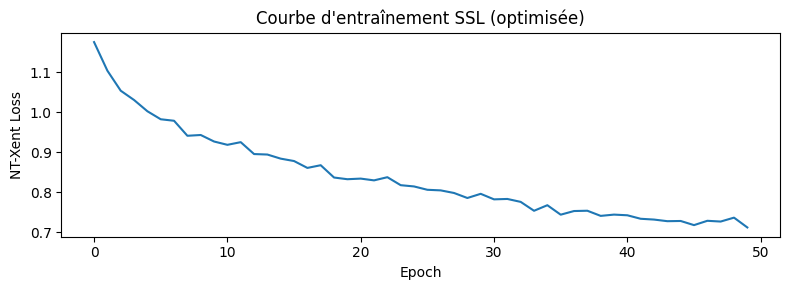

✅ Entraînement terminé


In [ ]:
import torch
import torch.nn.functional as F
from torch.cuda.amp import GradScaler
import matplotlib.pyplot as plt

loss_history = []

encoder.train()
proj_head.train()

use_amp = torch.cuda.is_available()
scaler = GradScaler(enabled=use_amp)

for epoch in range(1, EPOCHS + 1):
    epoch_loss = 0.0
    n_batches  = 0

    for (x1, x2) in loader:
        x1, x2 = x1.to(device), x2.to(device)

        optimizer.zero_grad()

        # 🔥 Mixed precision
        with autocast(enabled=use_amp):
            z1 = proj_head(encoder(x1))
            z2 = proj_head(encoder(x2))

            # ✅ NORMALISATION (ultra important)
            z1 = F.normalize(z1, dim=1)
            z2 = F.normalize(z2, dim=1)

            loss = nt_xent_loss(z1, z2, temperature=0.1)

        # 🚨 NaN protection
        if torch.isnan(loss) or torch.isinf(loss):
            print(f"⚠️ NaN/Inf détecté epoch {epoch} — batch skip")
            continue

        # 🔥 Backprop avec AMP
        scaler.scale(loss).backward()

        # Gradient clipping
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(
            list(encoder.parameters()) + list(proj_head.parameters()),
            max_norm=1.0
        )

        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
        n_batches  += 1

    # Scheduler (souvent par epoch)
    scheduler.step()

    if n_batches > 0:
        avg = epoch_loss / n_batches
        loss_history.append(avg)

        lr = optimizer.param_groups[0]['lr']

        print(f"Epoch {epoch:3d}/{EPOCHS} — Loss: {avg:.4f} — LR: {lr:.6f}")
    else:
        print(f"Epoch {epoch:3d}/{EPOCHS} — ⚠️ Aucun batch valide")

# 📊 Plot
plt.figure(figsize=(8, 3))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("NT-Xent Loss")
plt.title("Courbe d'entraînement SSL (optimisée)")
plt.tight_layout()
plt.show()

print("✅ Entraînement terminé")

In [67]:
import torch

checkpoint = {
    "encoder_state_dict": encoder.state_dict(),
    "proj_head_state_dict": proj_head.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "scheduler_state_dict": scheduler.state_dict(),
    "epoch": epoch,
    "loss_history": loss_history
}

torch.save(checkpoint, "ssl_model_checkpoint.pt")

print("✅ Modèle sauvegardé : ssl_model_checkpoint.pt")

✅ Modèle sauvegardé : ssl_model_checkpoint.pt


Epoch   1/50 — Loss: 0.7191 — LR: 0.000029
💾 Nouveau meilleur modèle sauvegardé
Epoch   2/50 — Loss: 0.7178 — LR: 0.000023
💾 Nouveau meilleur modèle sauvegardé
Epoch   3/50 — Loss: 0.7137 — LR: 0.000019
💾 Nouveau meilleur modèle sauvegardé
Epoch   4/50 — Loss: 0.7207 — LR: 0.000014
Epoch   5/50 — Loss: 0.7241 — LR: 0.000011
Epoch   6/50 — Loss: 0.7249 — LR: 0.000007
Epoch   7/50 — Loss: 0.7203 — LR: 0.000005
Epoch   8/50 — Loss: 0.7121 — LR: 0.000003
💾 Nouveau meilleur modèle sauvegardé
Epoch   9/50 — Loss: 0.7105 — LR: 0.000001
💾 Nouveau meilleur modèle sauvegardé
Epoch  10/50 — Loss: 0.7185 — LR: 0.000000
Epoch  11/50 — Loss: 0.6977 — LR: 0.000000
💾 Nouveau meilleur modèle sauvegardé
Epoch  12/50 — Loss: 0.7105 — LR: 0.000000
Epoch  13/50 — Loss: 0.7143 — LR: 0.000001
Epoch  14/50 — Loss: 0.7128 — LR: 0.000003
Epoch  15/50 — Loss: 0.7102 — LR: 0.000005
Epoch  16/50 — Loss: 0.7129 — LR: 0.000007
Epoch  17/50 — Loss: 0.7149 — LR: 0.000011
Epoch  18/50 — Loss: 0.7111 — LR: 0.000014
Epoc

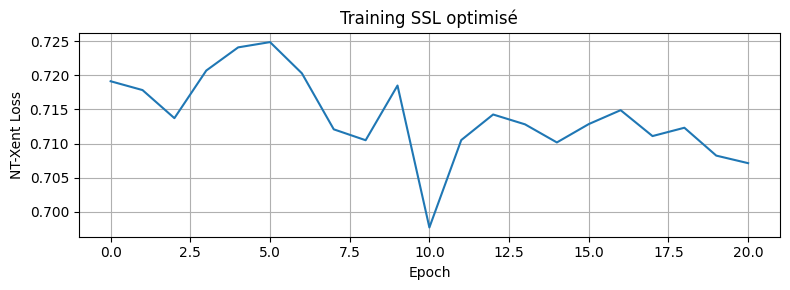

✅ Entraînement terminé


In [68]:
import torch
import torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler
import matplotlib.pyplot as plt

loss_history = []

encoder.train()
proj_head.train()

use_amp = torch.cuda.is_available()
scaler = GradScaler(enabled=use_amp)

best_loss = float("inf")
patience = 10
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    epoch_loss = 0.0
    n_batches  = 0

    for (x1, x2) in loader:
        x1, x2 = x1.to(device), x2.to(device)

        optimizer.zero_grad(set_to_none=True)

        with autocast(enabled=use_amp):
            z1 = proj_head(encoder(x1))
            z2 = proj_head(encoder(x2))

            # 🔥 NORMALISATION
            z1 = F.normalize(z1, dim=1)
            z2 = F.normalize(z2, dim=1)

            loss = nt_xent_loss(z1, z2, temperature=0.1)

        if not torch.isfinite(loss):
            continue

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(
            list(encoder.parameters()) + list(proj_head.parameters()),
            max_norm=1.0
        )

        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
        n_batches  += 1

    scheduler.step()

    if n_batches == 0:
        print(f"Epoch {epoch} — ⚠️ Aucun batch valide")
        continue

    avg = epoch_loss / n_batches
    loss_history.append(avg)

    lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch:3d}/{EPOCHS} — Loss: {avg:.4f} — LR: {lr:.6f}")

    # 🔥 Sauvegarde du meilleur modèle
    if avg < best_loss:
        best_loss = avg
        patience_counter = 0

        torch.save({
            "encoder": encoder.state_dict(),
            "proj_head": proj_head.state_dict(),
        }, "best_ssl_model.pt")

        print("💾 Nouveau meilleur modèle sauvegardé")

    else:
        patience_counter += 1

    # 🧠 Early stopping
    if patience_counter >= patience:
        print("🛑 Early stopping déclenché")
        break

# 📊 Plot
plt.figure(figsize=(8, 3))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("NT-Xent Loss")
plt.title("Training SSL optimisé")
plt.grid()
plt.tight_layout()
plt.show()

print("✅ Entraînement terminé")

# Extraction des embeddings

In [22]:
encoder.eval()
all_embeddings = []

infer_loader = DataLoader(
    torch.FloatTensor(X),
    batch_size=512,
    shuffle=False
)

with torch.no_grad():
    for batch in infer_loader:
        batch = batch.to(device)

        emb = encoder(batch)

        emb = torch.nn.functional.normalize(emb, dim=1)

        emb = emb.cpu().numpy()
        all_embeddings.append(emb)

embeddings = np.vstack(all_embeddings)

print(f"✅ Embeddings : {embeddings.shape}")
print(f"   NaN : {np.isnan(embeddings).sum()}")

assert not np.isnan(embeddings).any(), "❌ NaN dans les embeddings !"

✅ Embeddings : (19556, 32)
   NaN : 0


# Clustering HDBSCAN

In [23]:
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score
import umap
import hdbscan
import numpy as np

# 🔥 Normalisation
embeddings = normalize(embeddings)

# 🔥 UMAP
reducer = umap.UMAP(
    n_components=10,
    n_neighbors=30,
    min_dist=0.0,
    metric="cosine",
    random_state=SEED
)

emb_umap = reducer.fit_transform(embeddings)

# 🔥 HDBSCAN
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=30,
    min_samples=10,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

labels = clusterer.fit_predict(emb_umap)
probs  = clusterer.probabilities_

# 📊 Stats
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise    = (labels == -1).sum()

print(f"✅ Clusters trouvés  : {n_clusters}")
print(f"   Bruit (-1)        : {n_noise:,} ({n_noise/len(labels)*100:.1f}%)")

# 🔥 Filtrage par confiance
mask_valid = (labels != -1) & (probs > 0.3)

if mask_valid.sum() > 1 and n_clusters > 1:
    sil = silhouette_score(
        emb_umap[mask_valid],
        labels[mask_valid],
        sample_size=min(5000, mask_valid.sum())
    )
    print(f"   Silhouette score  : {sil:.4f}")

print(f"   Points fiables    : {mask_valid.sum():,}")

✅ Clusters trouvés  : 123
   Bruit (-1)        : 2,269 (11.6%)
   Silhouette score  : 0.5867
   Points fiables    : 17,041


In [25]:
from sklearn.metrics import silhouette_score
import hdbscan
import numpy as np

# Paramètres à tester
min_cluster_sizes = [20, 30, 40, 50]
min_samples_list  = [5, 10, 15]

results = []

for mcs in min_cluster_sizes:
    for ms in min_samples_list:
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=mcs,
            min_samples=ms,
            metric="euclidean",
            cluster_selection_method="eom",
            prediction_data=True
        )
        labels = clusterer.fit_predict(emb_umap)
        probs  = clusterer.probabilities_

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise    = (labels == -1).sum()
        mask_valid = (labels != -1) & (probs > 0.3)

        if mask_valid.sum() > 1 and n_clusters > 1:
            sil = silhouette_score(
                emb_umap[mask_valid],
                labels[mask_valid],
                sample_size=min(5000, mask_valid.sum())
            )
        else:
            sil = np.nan

        results.append({
            "min_cluster_size": mcs,
            "min_samples": ms,
            "n_clusters": n_clusters,
            "n_noise": n_noise,
            "silhouette": sil,
            "points_fidèles": mask_valid.sum()
        })

# Affichage des résultats triés par silhouette
import pandas as pd
df_results = pd.DataFrame(results)
df_results = df_results.sort_values("silhouette", ascending=False)
print(df_results)

    min_cluster_size  min_samples  n_clusters  n_noise  silhouette  \
8                 40           15          95     2044    0.621781   
2                 20           15         161     2967    0.612403   
5                 30           15         123     2468    0.609495   
0                 20            5         212     2753    0.607461   
1                 20           10         175     2844    0.605110   
3                 30            5         140     2246    0.587331   
11                50           15          83     1623    0.580668   
6                 40            5         108     1692    0.578707   
4                 30           10         123     2269    0.577825   
7                 40           10          99     1651    0.566111   
10                50           10          84     1379    0.560715   
9                 50            5          87     1383    0.548800   

    points_fidèles  
8            17416  
2            16260  
5            16880  
0    

In [ ]:
best_config = df_results.iloc[0]
min_cluster_size = best_config["min_cluster_size"]
min_samples = best_config["min_samples"]


np.float64(15.0)

In [32]:
min_cluster_size = 40
min_samples = 15

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=min_cluster_size,
    min_samples=min_samples,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)
labels = clusterer.fit_predict(emb_umap)

In [80]:
import joblib
joblib.dump(reducer, "umap_reducer_10d.pkl")
joblib.dump(clusterer, "hdbscan_clusterer.pkl")
np.save("scene_labels.npy", labels)

# Visualisation UMAP 2D

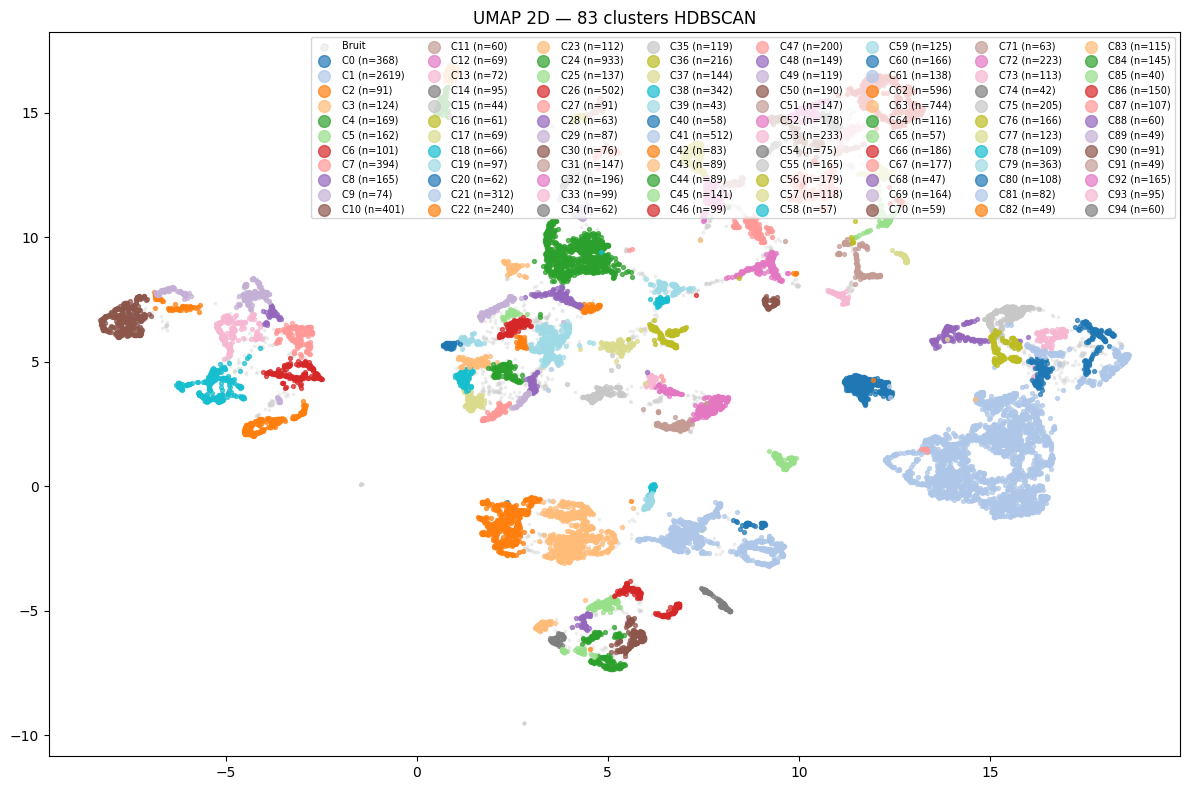

In [33]:
reducer_2d = UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=SEED
)
emb_2d = reducer_2d.fit_transform(embeddings)

df_scenes["cluster"] = labels
df_scenes["umap_x"]  = emb_2d[:, 0]
df_scenes["umap_y"]  = emb_2d[:, 1]

fig, ax = plt.subplots(figsize=(12, 8))

# Bruit en gris
noise_mask = labels == -1
ax.scatter(
    emb_2d[noise_mask, 0], emb_2d[noise_mask, 1],
    c="lightgrey", s=3, alpha=0.3, label="Bruit"
)

# Clusters colorés
palette = sns.color_palette("tab20", n_colors=max(n_clusters, 1))
for cid in sorted(set(labels) - {-1}):
    m = labels == cid
    ax.scatter(
        emb_2d[m, 0], emb_2d[m, 1],
        color=palette[cid % 20],
        s=8, alpha=0.7,
        label=f"C{cid} (n={m.sum()})"
    )

ax.set_title(f"UMAP 2D — {n_clusters} clusters HDBSCAN")
ax.legend(
    loc="upper right", markerscale=3,
    ncol=max(1, n_clusters // 10),
    fontsize=7
)
plt.tight_layout()
plt.show()

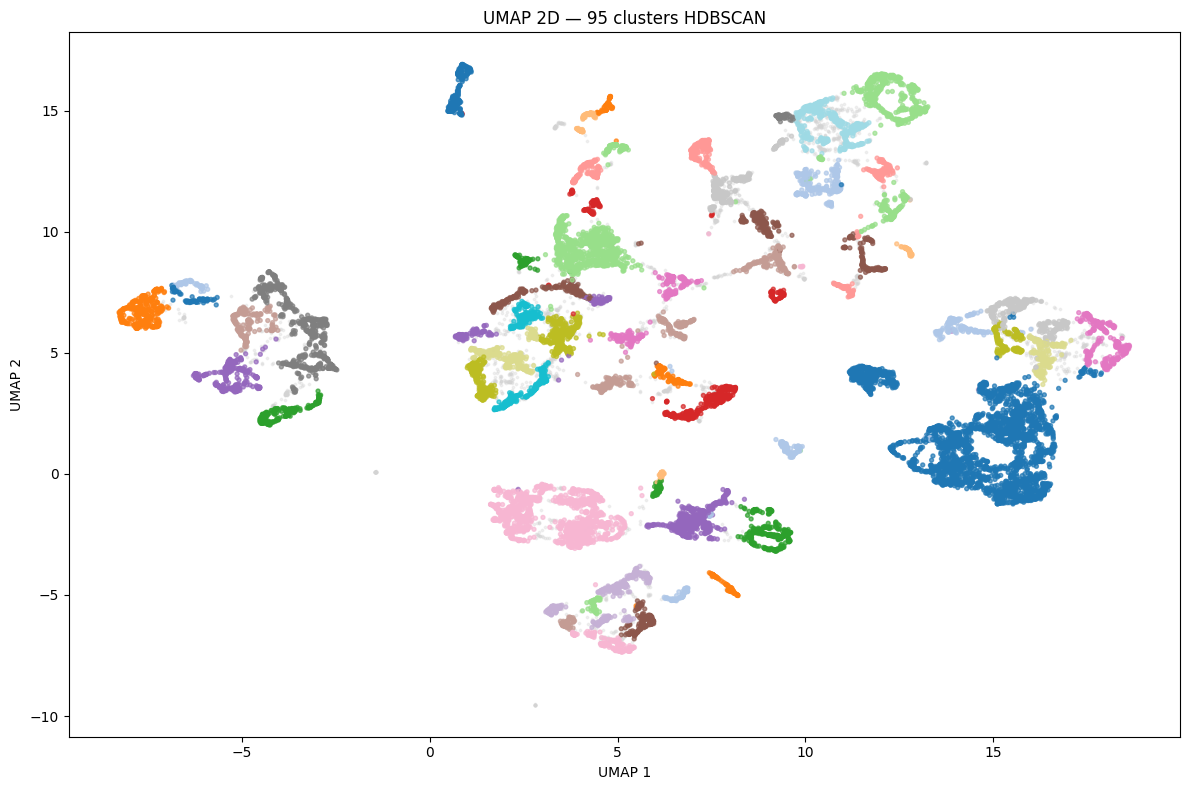

In [34]:
reducer_2d = UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=SEED,
    n_jobs=-1
)
df_scenes["cluster"] = labels
df_scenes["umap_x"] = emb_2d[:, 0]
df_scenes["umap_y"] = emb_2d[:, 1]

fig, ax = plt.subplots(figsize=(12, 8))

# Bruit en gris
noise_mask = labels == -1
ax.scatter(
    emb_2d[noise_mask, 0], emb_2d[noise_mask, 1],
    c="lightgrey", s=3, alpha=0.3
)

# Clusters colorés avec colormap
mask_clusters = labels != -1
num_clusters = len(set(labels) - {-1})
cmap = plt.cm.get_cmap("tab20", num_clusters)
sc = ax.scatter(
    emb_2d[mask_clusters, 0],
    emb_2d[mask_clusters, 1],
    c=[labels[i] for i in range(len(labels)) if labels[i] != -1],
    cmap=cmap,
    s=8,
    alpha=0.7
)

ax.set_title(f"UMAP 2D — {num_clusters} clusters HDBSCAN")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
plt.tight_layout()
plt.show()

In [35]:
# ── Cellule : profil détaillé de chaque cluster ──────────────────────────
df_scenes["cluster"] = labels

FEATURE_COLS_DISPLAY = [
    "pivot_speed", "pivot_navstatus", "pivot_rot",
    "pivot_length", "pivot_draught",
    "n_vessels_nearby", "mean_speed_nearby", "std_speed_nearby",
    "min_dist_other_nm", "frac_slow_nearby",
]

cluster_profile = (
    df_scenes[df_scenes["cluster"] != -1]
    .groupby("cluster")[FEATURE_COLS_DISPLAY]
    .agg(["mean", "median", "std"])
    .round(3)
)

# Taille de chaque cluster
cluster_sizes = (
    df_scenes[df_scenes["cluster"] != -1]
    .groupby("cluster")
    .size()
    .rename("n_scenes")
    .sort_values(ascending=False)
)

print(f"Top 15 clusters par taille :")
print(cluster_sizes.head(15))

Top 15 clusters par taille :
cluster
1     2619
24     933
63     744
62     596
41     512
26     502
10     401
7      394
0      368
79     363
38     342
21     312
22     240
53     233
72     223
Name: n_scenes, dtype: int64


In [36]:
# ── Cellule : règles heuristiques pour nommer les clusters ───────────────
# Basé sur les seuils AIS standard + connaissance maritime

def label_cluster(row):
    speed  = row["pivot_speed"]
    navst  = row["pivot_navstatus"]
    rot    = abs(row["pivot_rot"]) if not np.isnan(row["pivot_rot"]) else 0
    n_vois = row["n_vessels_nearby"]
    slow_f = row["frac_slow_nearby"]
    d_min  = row["min_dist_other_nm"]

    # Navstatus AIS explicite (quand disponible et fiable)
    if navst == 1:   return "ancré"
    if navst == 5:   return "amarré"
    if navst == 3:   return "restreint manœuvrabilité"

    # Règles comportementales
    if speed < 0.5:
        if n_vois > 3 and d_min < 0.5:  return "raft-up / bunkering candidat"
        return "à l'arrêt"

    if speed < 3.0 and rot > 10:        return "manœuvre port"

    if speed < 3.0 and n_vois > 5 and slow_f > 0.6:
        return "bunkering candidat"

    if speed > 12 and rot < 3 and n_vois < 3:
        return "transit rapide"

    if speed > 5 and rot > 15:          return "changement cap suspect"

    if n_vois == 0 and speed > 3:       return "vessel isolé"

    return "transit standard"


# Appliquer sur le profil median par cluster
cluster_mean = (
    df_scenes[df_scenes["cluster"] != -1]
    .groupby("cluster")[FEATURE_COLS_DISPLAY]
    .median()
)

cluster_mean["label_auto"]  = cluster_mean.apply(label_cluster, axis=1)
cluster_mean["n_scenes"]    = cluster_sizes
cluster_mean = cluster_mean.sort_values("n_scenes", ascending=False)

print(cluster_mean[["n_scenes", "label_auto",
                     "pivot_speed", "pivot_navstatus",
                     "n_vessels_nearby", "frac_slow_nearby"]].head(25))

         n_scenes                    label_auto  pivot_speed  pivot_navstatus  \
cluster                                                                         
1            2619  raft-up / bunkering candidat         0.10             -1.0   
24            933              transit standard         4.60             15.0   
63            744                        amarré         0.00              5.0   
62            596                        amarré         0.00              5.0   
41            512      restreint manœuvrabilité         0.00              3.0   
26            502  raft-up / bunkering candidat         0.00             15.0   
10            401                  vessel isolé         4.90              7.0   
7             394                        amarré         0.00              5.0   
0             368              transit standard         5.70             -1.0   
79            363              transit standard         7.80              7.0   
38            342           

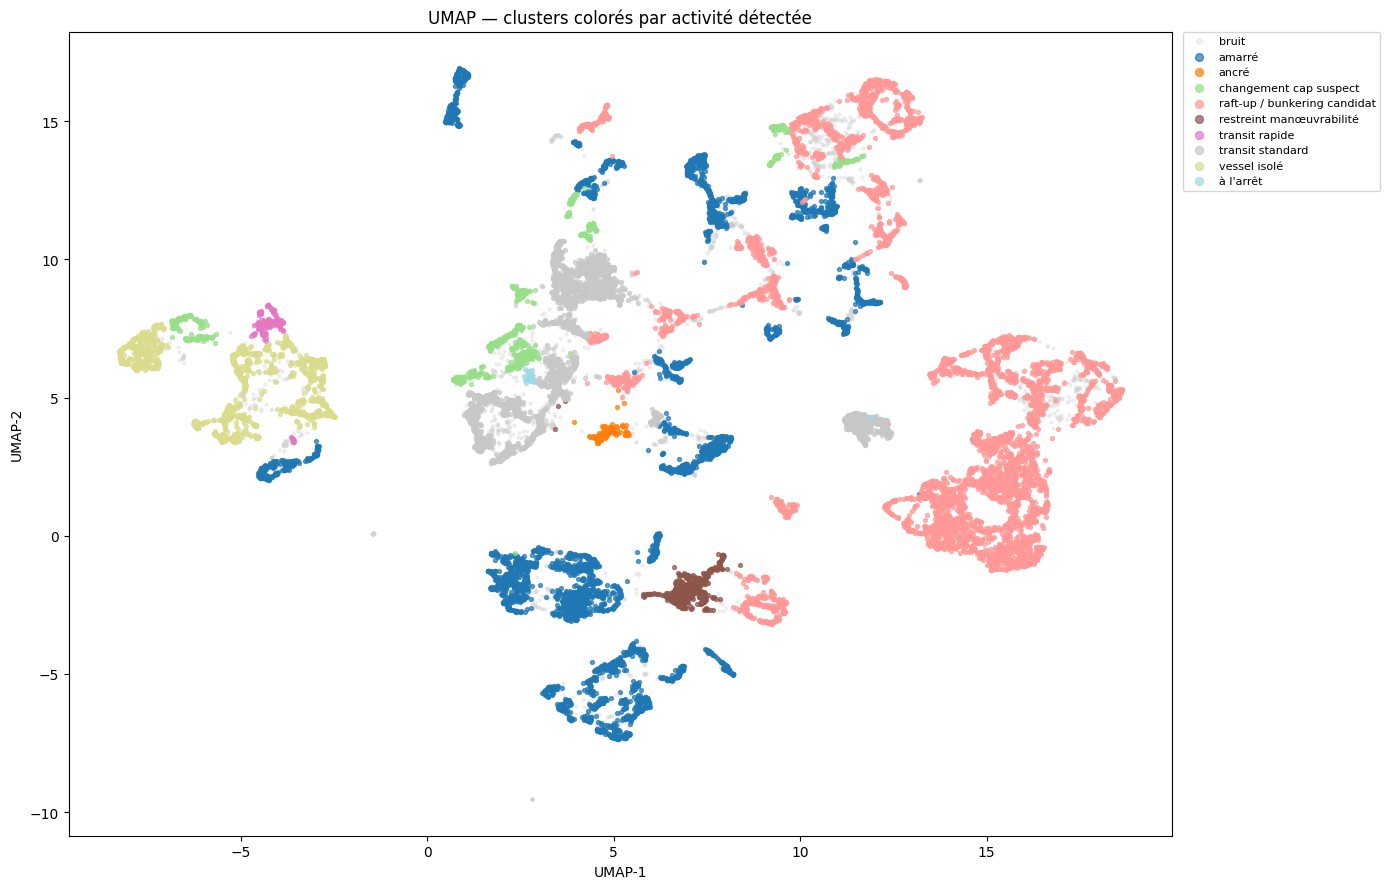

In [38]:
# ── Cellule : UMAP coloré par label automatique ──────────────────────────
label_to_cluster = cluster_mean["label_auto"].to_dict()
activities       = sorted(set(label_to_cluster.values()))
activity_palette = plt.cm.tab20(np.linspace(0, 1, len(activities)))
activity_colors  = {act: activity_palette[i] for i, act in enumerate(activities)}

fig, ax = plt.subplots(figsize=(14, 9))

# Bruit
noise = labels == -1
ax.scatter(emb_2d[noise, 0], emb_2d[noise, 1],
           c="lightgray", s=4, alpha=0.3, label="bruit")

# Par activité
for act in activities:
    clusters_of_act = [c for c, l in label_to_cluster.items() if l == act]
    mask = np.isin(labels, clusters_of_act)
    ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
               c=[activity_colors[act]], s=8, alpha=0.7, label=act)

ax.legend(markerscale=2, fontsize=8, loc="upper left",
          bbox_to_anchor=(1.01, 1), borderaxespad=0)
ax.set_title("UMAP — clusters colorés par activité détectée")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
plt.tight_layout()
plt.show()

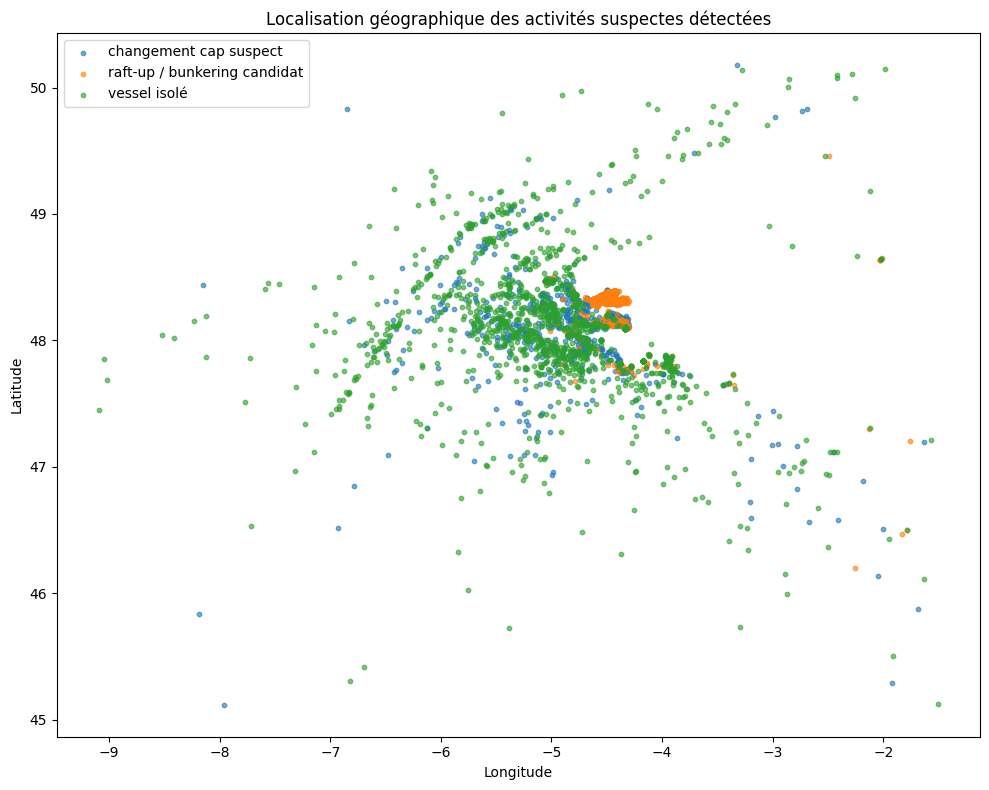

Scènes suspectes : 8,815 / 19,556 (45.1%)


In [39]:
# ── Cellule : carte géographique des clusters suspects ───────────────────
suspects = ["bunkering candidat", "raft-up / bunkering candidat",
            "changement cap suspect", "vessel isolé"]

df_suspect = df_scenes[
    df_scenes["cluster"].map(label_to_cluster).isin(suspects)
].copy()
df_suspect["activite"] = df_suspect["cluster"].map(label_to_cluster)

fig, ax = plt.subplots(figsize=(10, 8))
for act, grp in df_suspect.groupby("activite"):
    ax.scatter(grp["lon"], grp["lat"], s=10, alpha=0.6, label=act)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Localisation géographique des activités suspectes détectées")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Scènes suspectes : {len(df_suspect):,} / {len(df_scenes):,} "
      f"({len(df_suspect)/len(df_scenes)*100:.1f}%)")

# Profil opérationnel des clusters

=== Profil des clusters ===
        pivot_speed        pivot_navstatus        pivot_shiptype        n_vessels_nearby         min_dist_other_nm         frac_slow_nearby        pivot_length       
               mean median            mean median           mean median             mean  median              mean  median             mean median         mean median
cluster                                                                                                                                                               
0              4.93   5.70           -0.98   -1.0          31.97   31.5           395.45   278.5              2.09    1.29             0.13   0.02        13.70   12.0
1              1.74   0.10           -0.95   -1.0          34.30   36.0          2356.04  2254.0              0.22    0.04             0.60   0.61        14.28   11.0
2              7.07   7.90            1.85    0.0          81.31   79.0             0.00     0.0            999.00  999.00             0.

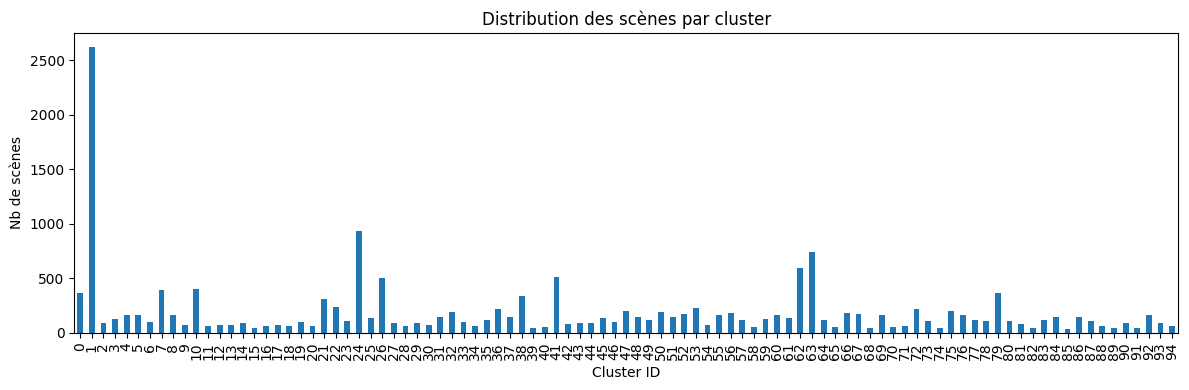

In [40]:
PROFILE_COLS = [
    "pivot_speed", "pivot_navstatus", "pivot_shiptype",
    "n_vessels_nearby", "min_dist_other_nm",
    "frac_slow_nearby", "pivot_length"
]

# Ajouter les features au df_scenes pour le profil
for col in FEATURE_COLS:
    if col not in df_scenes.columns:
        df_scenes[col] = df_feat[col].values

df_valid = df_scenes[df_scenes["cluster"] != -1]

cluster_profiles = (
    df_valid.groupby("cluster")[PROFILE_COLS]
    .agg(["mean","median"])
    .round(2)
)

print("=== Profil des clusters ===")
print(cluster_profiles.to_string())

# Taille des clusters
fig, ax = plt.subplots(figsize=(12, 4))
df_valid["cluster"].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_xlabel("Cluster ID")
ax.set_ylabel("Nb de scènes")
ax.set_title("Distribution des scènes par cluster")
plt.tight_layout()
plt.show()

# Sauvegarde

In [85]:
import joblib

torch.save(encoder.state_dict(), "maritime_encoder.pt")
joblib.dump(scaler,    "scaler.pkl")
joblib.dump(reducer,   "umap_reducer_10d.pkl")
joblib.dump(clusterer, "hdbscan_clusterer.pkl")

print("✅ Sauvegardé :")
print("   maritime_encoder.pt")
print("   scaler.pkl")
print("   umap_reducer_10d.pkl")
print("   hdbscan_clusterer.pkl")
print("   maritime_scenes_clustered.parquet")

✅ Sauvegardé :
   maritime_encoder.pt
   scaler.pkl
   umap_reducer_10d.pkl
   hdbscan_clusterer.pkl
   maritime_scenes_clustered.parquet


# Inférence sur nouvelles scènes

In [4]:
import joblib

# Charger le DataFrame depuis le fichier .pkl
df_scenes = joblib.load("df_scenes.pkl")

# Vérifier que ça a bien fonctionné
df_scenes.head(3)

,pivot_speed,pivot_course,pivot_heading,pivot_navstatus,pivot_rot,pivot_shiptype,pivot_length,pivot_draught,n_vessels_nearby,mean_speed_nearby,std_speed_nearby,min_dist_other_nm,mean_dist_other_nm,frac_slow_nearby,sourcemmsi,t,lon,lat
0,8.5,266.0,511.0,0.0,-127.0,96.0,20.0,3.5,670,7.200448,0.688227,0.249479,1.876011,0.000000,228157000,2015-10-08 02:30:00+00:00,-4.640700,48.107580
1,0.0,183.5,147.0,7.0,0.0,30.0,22.0,0.0,1565,0.052780,1.051280,0.051912,0.347430,0.998083,227577000,2015-11-22 20:00:00+00:00,-4.486422,48.381840
2,0.1,320.3,345.0,1.0,0.0,70.0,111.0,5.0,277,0.908303,2.461157,0.956325,7.017058,0.866426,244810418,2015-10-20 12:00:00+00:00,-4.497585,48.197945


In [17]:
checkpoint = torch.load("best_ssl_model.pt", map_location=device)
encoder.load_state_dict(checkpoint["encoder"])
proj_head.load_state_dict(checkpoint["proj_head"])

encoder.eval()
proj_head.eval()

ProjectionHead(
  (net): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=64, out_features=64, bias=True)
  )
)

In [41]:
from sklearn.metrics import silhouette_score
import numpy as np
import hdbscan

# 🔥 Meilleure config trouvée
min_cluster_size = int(best_config["min_cluster_size"])
min_samples = int(best_config["min_samples"])

# 🔥 Fit HDBSCAN
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=min_cluster_size,
    min_samples=min_samples,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)
labels = clusterer.fit_predict(emb_umap)
probs = clusterer.probabilities_

# 🔥 Stats de base
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = (labels == -1).sum()

# 🔥 Filtrage par confiance
mask_valid = (labels != -1) & (probs > 0.3)

# 🔥 Silhouette score
if mask_valid.sum() > 1 and n_clusters > 1:
    sil = silhouette_score(
        emb_umap[mask_valid],
        labels[mask_valid],
        sample_size=min(5000, mask_valid.sum())
    )
else:
    sil = np.nan

# 🔥 Affichage
print(f"✅ Meilleure configuration : min_cluster_size={min_cluster_size}, min_samples={min_samples}")
print(f"   Clusters trouvés  : {n_clusters}")
print(f"   Points bruit (-1) : {n_noise:,} ({n_noise/len(labels)*100:.1f}%)")
print(f"   Points fiables     : {mask_valid.sum():,}")
print(f"   Silhouette score   : {sil:.4f}")

✅ Meilleure configuration : min_cluster_size=40, min_samples=15
   Clusters trouvés  : 95
   Points bruit (-1) : 2,044 (10.5%)
   Points fiables     : 17,416
   Silhouette score   : 0.6183
